<a href="https://colab.research.google.com/github/adarsha4real/pytorch-basics/blob/main/Computer_Vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Some important computer vision libraries
`torchvision`- base domain library for pytorch computer vision

`torchvision.datasets` - get dataset and data loading functions for computer vision

`torchvision.models`-get pretrained computer vision models

`torchvision.transforms`-function for manipulating your vision data(images) for use with an ML model

In [4]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision import transforms

from torchvision.transforms import ToTensor


# import matplotlib
import matplotlib.pyplot as plt

print( torch.__version__)
print(torchvision.__version__)


2.11.0+cu128
0.26.0+cu128


## Getting a datasets
we will be using FashionMNIST from torchvisoin.datasets

---



In [5]:
# setup training data
train_data= datasets.FashionMNIST(root="data",
                                  train=True,
                                  download=True,
                                  transform=torchvision.transforms.ToTensor(),
                                  target_transform=None)
test_data= datasets.FashionMNIST(root="data",
                                  train=False,
                                  download=True,
                                  transform=torchvision.transforms.ToTensor(),
                                  target_transform=None)

train_data,test_data

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 165kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.16MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.40MB/s]


(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

In [6]:
image,label = train_data[0]
image,label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [7]:
class_names= train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [8]:
class_to_idx= train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [9]:
# check the shape of our image
image.shape,label

(torch.Size([1, 28, 28]), 9)

image shape: torch.Size([1, 28, 28]), label: 9


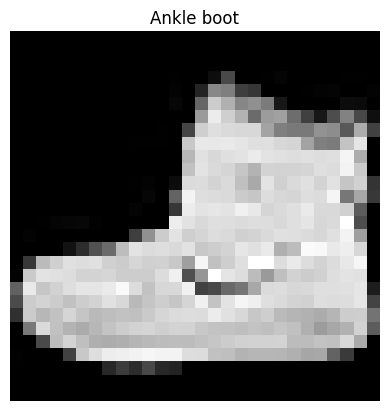

In [10]:
# visualizing data
import matplotlib.pyplot as plt
image,label = train_data[0]
print(f"image shape: {image.shape}, label: {label}")
plt.imshow(image.squeeze(),cmap="gray")
plt.title(class_names[label])
plt.axis("off")
plt.show()

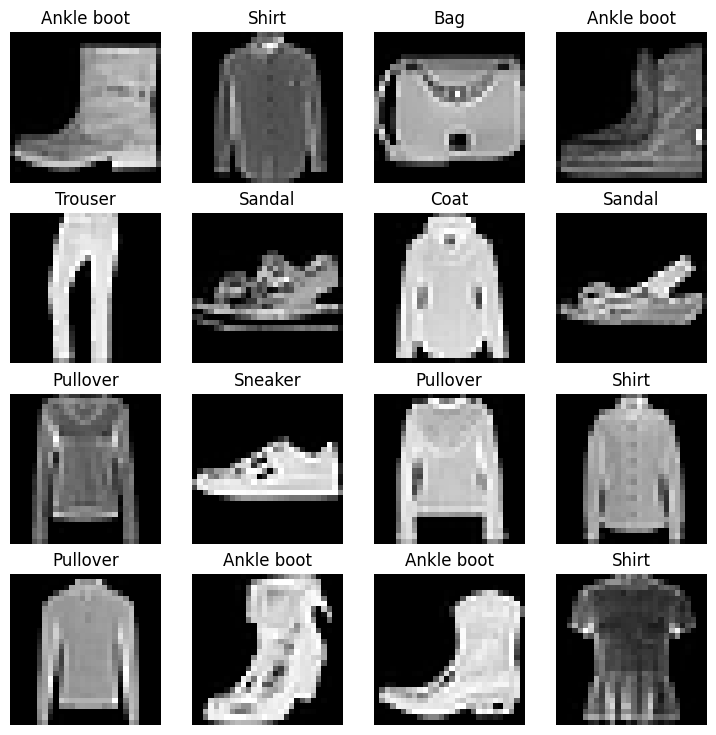

In [11]:
# plot more data
torch.manual_seed(42)
fig=plt.figure(figsize=(9,9))
rows,cols = 4,4
for i in range(1,rows*cols+1):
  random_idx = torch.randint(0,len(train_data),size=[1]).item()
  img,label= train_data[random_idx]
  fig.add_subplot(rows,cols,i)
  plt.imshow(img.squeeze(),cmap="gray")
  plt.title(class_names[label])
  plt.axis(False);

In [12]:

# prepare data loader
# a data loader turns our dataset into a python iterable


from torch.utils.data import DataLoader
# setup batchsize
BATCH_SIZE=32

# TURN DATASETS INTO ITERTABLE
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)
test_dataloader = DataLoader(dataset=test_data,
                              batch_size=BATCH_SIZE,
                              shuffle=False)
train_dataloader,test_dataloader
#

(<torch.utils.data.dataloader.DataLoader at 0x7dd1f51c67e0>,
 <torch.utils.data.dataloader.DataLoader at 0x7dd1f5369670>)

In [13]:
train_features_batch,train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape,train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

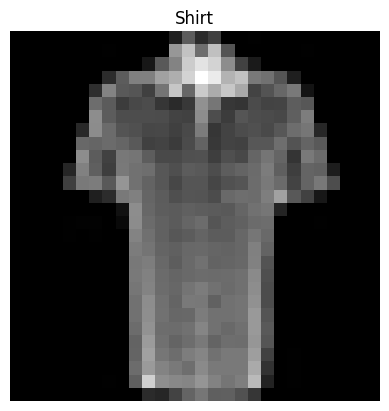

In [14]:
# show a sample

torch.manual_seed(42)
random_idx = torch.randint(0,len(train_features_batch) , size=[1]).item()
img,label= train_features_batch[random_idx],train_labels_batch[random_idx]
plt.imshow(img.squeeze(),cmap="gray")
plt.title(class_names[label])
plt.axis(False);

#### Buid a baseline model

In [15]:
# creating a flatten layer
flatten_model = nn.Flatten()
# get a single sample
x = train_features_batch[0]
x.shape

# lets flatten the sample
output = flatten_model(x)
output.shape

torch.Size([1, 784])

In [16]:
from torch import nn
class FashionMNISTModelv0(nn.Module):
  def __init__(self,
               input_shape:int,
               hidden_units:int,
               output_shape:int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,
                  out_features=hidden_units),
        nn.Linear(in_features=hidden_units,
                  out_features=output_shape)
    )
  def forward(self,x):
    return self.layer_stack(x)





In [17]:
torch.manual_seed(42)
model_0 = FashionMNISTModelv0(
    input_shape=784,
    hidden_units=10,
    output_shape=len(class_names)

).to("cpu") # Changed .to('cpu') to .to(device)

model_0

FashionMNISTModelv0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [18]:
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print("helper functions already exists")
else:
  print("downloading helper functions")
  request= requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py","wb") as f:
    f.write(request.content)

downloading helper functions


In [19]:

# setup loss and optimizer
# def accuracy_fn(y_true,y_pred):
#   correct = torch.eq(y_true,y_pred).sum().item()
#   acc=(correct/len(y_pred))*100
#   return acc


from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)

In [20]:
# creating a function to time our experiment
from timeit import default_timer as  timer
def print_train_time(start:float,
                     end:float,
                     device:torch.device=None
                     ):
  total_time= end-start
  print(f"train time on {device}:{total_time:.3f} seconds")
  return total_time


In [21]:
from numpy.matrixlib import test
# import tqdm for progress bar
from tqdm.auto import tqdm

torch.manual_seed(42)
train_time_start_on_cpu= timer()

# set the number of epochs
epochs = 3
# creating a train and test loop
for epoch in tqdm(range(epochs)):
  print(f"epoch:{epoch}\n-----")
  # training
  train_loss = 0
  # add a loop to loop through our batches
  for batch,(X,y) in enumerate(train_dataloader):
    model_0.train()
    y_pred = model_0(X)
    loss = loss_fn(y_pred,y)
    train_loss += loss
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if batch % 400 == 0:
      print(f"look at batch:{batch} loss:{loss.item()}")
  train_loss /= len(train_dataloader)
  # testing



  test_loss,test_acc = 0,0
  model_0.eval()
  with torch.inference_mode():
    for x_test,y_test in test_dataloader:
      test_pred = model_0(x_test)
      test_loss += loss_fn(test_pred,y_test)
      test_acc += accuracy_fn(y_true=y_test,
                              y_pred=test_pred.argmax(dim=1))

    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)
  print(f"train loss:{train_loss:.5f} | test loss:{test_loss:.5f} | test acc:{test_acc:.2f}%")

train_time_end_on_cpu= timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu,end=train_time_end_on_cpu,device=str(next(model_0.parameters())))
print(f"total training time:{print_train_time(start=train_time_start_on_cpu,end=train_time_end_on_cpu,device='cpu')}")


  0%|          | 0/3 [00:00<?, ?it/s]

epoch:0
-----
look at batch:0 loss:2.366476535797119
look at batch:400 loss:0.6423891186714172
look at batch:800 loss:0.5696730613708496
look at batch:1200 loss:0.3812875747680664
look at batch:1600 loss:0.34902697801589966
train loss:0.59039 | test loss:0.50954 | test acc:82.04%
epoch:1
-----
look at batch:0 loss:0.3799288272857666
look at batch:400 loss:0.6835907101631165
look at batch:800 loss:0.3863295018672943
look at batch:1200 loss:0.6464131474494934
look at batch:1600 loss:0.26915842294692993
train loss:0.47633 | test loss:0.47989 | test acc:83.20%
epoch:2
-----
look at batch:0 loss:0.36813658475875854
look at batch:400 loss:0.7437165379524231
look at batch:800 loss:0.2938009202480316
look at batch:1200 loss:0.3958978056907654
look at batch:1600 loss:0.3783450722694397
train loss:0.45503 | test loss:0.47664 | test acc:83.43%
train time on Parameter containing:
tensor([[ 0.0273,  0.0298, -0.0065,  ...,  0.0071,  0.0091,  0.0170],
        [-0.0189, -0.0355,  0.0155,  ...,  0.0161

In [22]:
next(model_0.parameters()).device



device(type='cpu')

##make prediction and get model_0 result

In [23]:
from os import environ
# device="cuda" if torch.cuda.is_available() else "cpu"

torch.manual_seed(42)
def eval_model(model:torch.nn.Module,
               data_loader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               device:torch.device,
               accuracy_fn):
  loss,acc= 0,0
  model.eval()
  with torch.inference_mode():
    for x,y in data_loader:
      x, y = x.to(device), y.to(device) # Move data to the specified device
      # make prediction
      y_pred=model(x)
      # accumulate the loss and acc_fn
      loss+= loss_fn(y_pred,y)
      acc+= accuracy_fn(y_true=y,
                        y_pred=y_pred.argmax(dim=1))
    loss /= len(data_loader)
    acc /= len(data_loader)
  return {"model_name":model.__class__.__name__,
          "model_loss":loss.item(),
          "model_acc":acc}



model_0_results = eval_model(model=model_0,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn,
                             device="cpu"
                             )
model_0_results

{'model_name': 'FashionMNISTModelv0',
 'model_loss': 0.47663888335227966,
 'model_acc': 83.42651757188499}

creating and training model in gpu


In [24]:
device ="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

Buiding a better model with non linearity

In [25]:
class FashionMNISTModelv1(nn.Module):
  def __init__(self,input_shape:int,
               hidden_units:int,
               output_shape:int):
    super().__init__()
    self.layer_stack= nn.Sequential(
        nn.Flatten(),#flatten he input
        nn.Linear(in_features=input_shape,
                    out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,
                  out_features=output_shape),
        nn.ReLU()
    )

  def forward(self,x:torch.Tensor):
      return self.layer_stack(x)





In [26]:
next(model_0.parameters()).device

device(type='cpu')

In [27]:
# create an instance of model_1
torch.manual_seed(42)
model_1=FashionMNISTModelv1(input_shape=28*28,
                            hidden_units=10,
                            output_shape=len(class_names)).to(device)
next(model_1.parameters()).device
#

device(type='cuda', index=0)

In [28]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.1)

Creating a training_loop and testing_Loop function

In [29]:
def train_step(model:torch.nn.Module,
                data_loader:torch.utils.data.DataLoader,
                loss_fn:torch.nn.Module,
                optimizer:torch.optim.Optimizer,
                accuracy_fn,
                device:torch.device):
  train_loss,train_acc=0,0
  model.train()



  # add a loop to loop through our batches
  for batch,(X,y) in enumerate(data_loader):
    X,y = X.to(device),y.to(device)

    y_pred = model(X)
    loss = loss_fn(y_pred,y)
    train_loss += loss
    train_acc += accuracy_fn(y_true=y,
                              y_pred=y_pred.argmax(dim=1))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  print(f"look at batch:{batch} loss:{train_loss:.5f} || train_acc:{train_acc:.2f}%")


In [30]:
def test_step(model:torch.nn.Module,
              data_loader:torch.utils.data.DataLoader,
              loss_fn:torch.nn.Module,

              accuracy_fn,
              device:torch.device):
  test_loss,test_acc = 0,0
  model.eval()
  with torch.inference_mode():
    for X,y in data_loader:
      X,y = X.to(device),y.to(device)
      # forward pass
      test_pred = model(X)
      # loss
      test_loss += loss_fn(test_pred,y)
      test_acc += accuracy_fn(y_true=y,
                              y_pred=test_pred.argmax(dim=1))
    test_loss /= len(data_loader)
    test_acc /= len(data_loader)
    print(f"test_loss:{test_loss:.5f} | test_acc:{test_acc:.2f}%\n")




In [31]:

torch.manual_seed(42)
#measure time
from timeit import default_timer as timer
train_time_start_on_gpu = timer()



# epochs

epochs = 3


# create a optimization and evaluation loop using train_step() and test_step()
for epoch in tqdm(range(epochs)):
  print(f"epoch:{epoch}\n-----")
  train_step(model=model_1,
             data_loader=train_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn,
             device=device)
  test_step(model=model_1,
            data_loader=test_dataloader,
            loss_fn=loss_fn,

            accuracy_fn=accuracy_fn,
            device=device)

train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu,end=train_time_end_on_gpu,device=str(device))

  0%|          | 0/3 [00:00<?, ?it/s]

epoch:0
-----
look at batch:1874 loss:1.09199 || train_acc:61.34%
test_loss:0.95636 | test_acc:65.00%

epoch:1
-----
look at batch:1874 loss:0.78101 || train_acc:71.93%
test_loss:0.72227 | test_acc:73.91%

epoch:2
-----
look at batch:1874 loss:0.67027 || train_acc:75.94%
test_loss:0.68500 | test_acc:75.02%

train time on cuda:33.116 seconds


In [32]:
next(model_1.parameters()).device

device(type='cuda', index=0)

In [33]:
model_0_results

{'model_name': 'FashionMNISTModelv0',
 'model_loss': 0.47663888335227966,
 'model_acc': 83.42651757188499}

In [34]:
#  # Temporarily move model to CPU to match eval_model's hardcoded CPU data
# model_1_results = eval_model(model=model_1,
#                              data_loader=test_dataloader, # Changed from test_data to test_dataloader
#                              loss_fn=loss_fn,
#                              accuracy_fn=accuracy_fn,
#                              device="cpu") # Pass "cpu" to align with model's temporary device for this call
# model_1.to(device) # Move model back to its original device (CUDA)
# model_1_results

In [35]:
next(model_1.parameters()).device

device(type='cuda', index=0)

Build a CNN

In [69]:
class FashionMNISTModelv2(nn.Module):
  def __init__(self,input_shape:int,
               hidden_units:int,
               output_shape:int):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1
                  ),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)

    )
    self.conv_block_2=nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1
                  ),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7,
                  out_features=output_shape)
    )
  def forward(self,x):
    x = self.conv_block_1(x)
    x = self.conv_block_2(x)
    x = self.classifier(x)
    return x

#


In [37]:
torch.manual_seed(42)
model_2 = FashionMNISTModelv2(input_shape=1,
                              hidden_units=10,
                              output_shape=len(class_names)).to(device)
model_2

FashionMNISTModelv2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

understanding conv2d


In [38]:
torch.manual_seed(42)
# create a batch of images
images = torch.randn(size=(32,3,64,64))
test_image = images[0]
test_image.shape
test_image.unsqueeze(dim=0)

tensor([[[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
          [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
          [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
          ...,
          [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
          [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
          [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

         [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
          [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
          [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
          ...,
          [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
          [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,  2.2465],
          [-1.3242, -0.1973,  0.2920,  ...,  0.5409,  0.6940,  1.8563]],

         [[-0.7978,  1.0261,  1.1465,  ...,  1.2134,  0.9354, -0.0780],
          [-1.4647, -1.9571,  

In [39]:
# create a single conv2d layers
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=10,
                       kernel_size=3,stride=1,
                       padding=0)
conv_output=conv_layer(test_image.unsqueeze(0))
conv_output

tensor([[[[-2.8778e-01, -6.0596e-02, -5.6306e-02,  ...,  2.8654e-01,
            6.6224e-01, -2.3216e-01],
          [-9.8911e-01, -4.0099e-01,  4.1832e-01,  ...,  4.7459e-01,
           -1.8552e-01, -5.7622e-01],
          [-4.1340e-02, -2.3277e-01,  3.7418e-01,  ...,  2.8255e-02,
            1.4923e-01,  1.4236e-01],
          ...,
          [-8.0374e-01, -7.6687e-01, -5.9457e-02,  ...,  1.7452e-01,
            4.2594e-01, -4.8341e-01],
          [-1.4512e-01, -1.1566e-01,  6.1783e-01,  ...,  2.4126e-01,
           -3.6626e-01,  3.5645e-01],
          [ 3.6096e-02,  1.5214e-01,  2.3123e-01,  ...,  3.0904e-01,
           -4.9680e-01, -7.2258e-01]],

         [[-1.0853e+00, -1.6079e+00,  1.3346e-01,  ...,  2.1698e-01,
           -1.7643e+00,  2.5263e-01],
          [-8.2507e-01,  6.3866e-01,  1.8845e-01,  ..., -1.0936e-01,
            4.8068e-01,  8.4869e-01],
          [ 6.4927e-01, -4.2061e-03, -4.9991e-01,  ...,  5.8356e-01,
            2.4611e-01,  6.6233e-01],
          ...,
     

In [40]:
test_image.shape

torch.Size([3, 64, 64])

In [41]:
conv_output.shape

torch.Size([1, 10, 62, 62])

In [42]:
# training our CNN model
# 1.setup loss and optimizer
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer= torch.optim.SGD(params=model_2.parameters(),
                            lr=0.1)
model_2.state_dict()

OrderedDict([('conv_block_1.0.weight',
              tensor([[[[ 0.2548,  0.2767, -0.0781],
                        [ 0.3062, -0.0730,  0.0673],
                        [-0.1623,  0.1958,  0.2938]]],
              
              
                      [[[-0.2445,  0.2897,  0.0624],
                        [ 0.2463,  0.0451,  0.1607],
                        [-0.0471,  0.2570,  0.0493]]],
              
              
                      [[[-0.1556,  0.0850, -0.1536],
                        [-0.0391, -0.1354,  0.2211],
                        [-0.2631, -0.1537, -0.0941]]],
              
              
                      [[[-0.2004,  0.0315, -0.3292],
                        [ 0.3010, -0.2832,  0.2573],
                        [ 0.0555, -0.1082,  0.2060]]],
              
              
                      [[[ 0.0520,  0.2693,  0.0364],
                        [-0.1051,  0.0896, -0.0904],
                        [ 0.1403,  0.2976,  0.1927]]],
              
              
      

In [43]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# measure time
from timeit import default_timer as timer
train_time_start_model_2 = timer()


# train and test loop
epochs = 3
for epoch in tqdm(range(epochs)):
  print(f"Epoch:{epoch}\n.....")
  train_step(model=model_2,data_loader=train_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn,
             device=device)
  test_step(model=model_2,
            data_loader=test_dataloader,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn,
            device=device)

train_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(start=train_time_start_model_2,end=train_time_end_model_2,device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch:0
.....
look at batch:1874 loss:0.59344 || train_acc:78.44%
test_loss:0.41582 | test_acc:85.39%

Epoch:1
.....
look at batch:1874 loss:0.36623 || train_acc:86.73%
test_loss:0.35344 | test_acc:86.95%

Epoch:2
.....
look at batch:1874 loss:0.32796 || train_acc:88.09%
test_loss:0.32149 | test_acc:88.38%

train time on cuda:38.429 seconds


In [44]:
# get model_2 result
model_2_results=eval_model(model=model_2,
                           data_loader=test_dataloader,
                           loss_fn=loss_fn,
                           accuracy_fn=accuracy_fn,
                           device=device)
model_2_results


{'model_name': 'FashionMNISTModelv2',
 'model_loss': 0.3214859068393707,
 'model_acc': 88.37859424920129}

In [45]:
device

'cuda'

In [46]:
model_0_results

{'model_name': 'FashionMNISTModelv0',
 'model_loss': 0.47663888335227966,
 'model_acc': 83.42651757188499}

In [47]:
# compare all models
import pandas as pd
compare_model= pd.DataFrame([model_0_results,model_2_results])
compare_model

,model_name,model_loss,model_acc
0,FashionMNISTModelv0,0.476639,83.426518
1,FashionMNISTModelv2,0.321486,88.378594


In [48]:
compare_model["training_time"]=[total_train_time_model_0,total_train_time_model_2]

In [49]:
compare_model

,model_name,model_loss,model_acc,training_time
0,FashionMNISTModelv0,0.476639,83.426518,29.295745
1,FashionMNISTModelv2,0.321486,88.378594,38.428599


Text(0.5, 1.0, 'compare model accuracy')

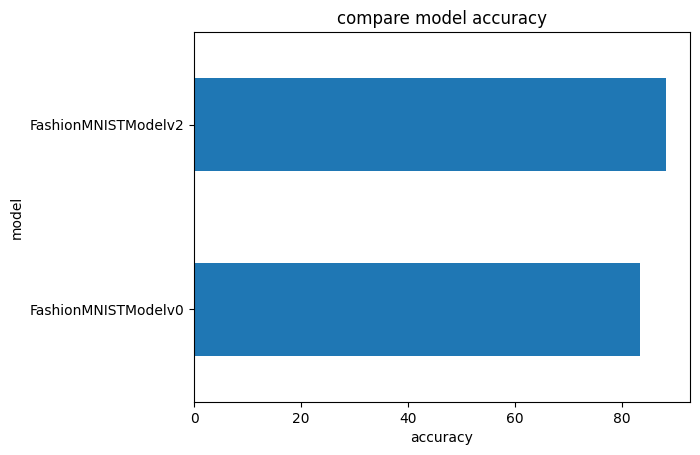

In [50]:
# visualize our model
compare_model.set_index("model_name")["model_acc"].plot(kind="barh")
plt.xlabel("accuracy")
plt.ylabel("model")
plt.title("compare model accuracy")

make prediction


In [51]:
def make_predictions(model:torch.nn.Module,
                     data:list,
                     device:torch.device=device

                     ):
  pred_probs=[]
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for sample in data:
      # prepare the sample
      sample = torch.unsqueeze(sample,dim=0).to(device)

      # forward pass
      pred_logits=model(sample)
      # get prediction probability
      pred_prob = torch.softmax(pred_logits,dim=1)
      pred_probs.append(pred_prob.cpu())
  return torch.cat(pred_probs,dim=0)



In [52]:
import random
random.seed(42)
test_samples =[]
test_labels =[]
for sample,label in random.sample(list(test_data),k=9):
  test_samples.append(sample)
  test_labels.append(label)

# view th first sample shape
test_samples[0].shape



torch.Size([1, 28, 28])

In [53]:
# make prediction
pred_probs = make_predictions(model=model_2,data=test_samples)

# view first two prediction probability
pred_probs[:2]

tensor([[9.6824e-08, 6.1714e-09, 3.6363e-08, 3.0031e-07, 4.9359e-09, 9.9993e-01,
         3.0864e-07, 8.1508e-06, 7.5984e-06, 4.8662e-05],
        [5.0791e-02, 5.4277e-01, 1.1577e-03, 1.0961e-01, 7.1946e-02, 1.2252e-04,
         2.2231e-01, 4.6993e-04, 3.7545e-04, 4.4629e-04]])

In [54]:
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([5, 1, 7, 4, 3, 0, 4, 7, 1])

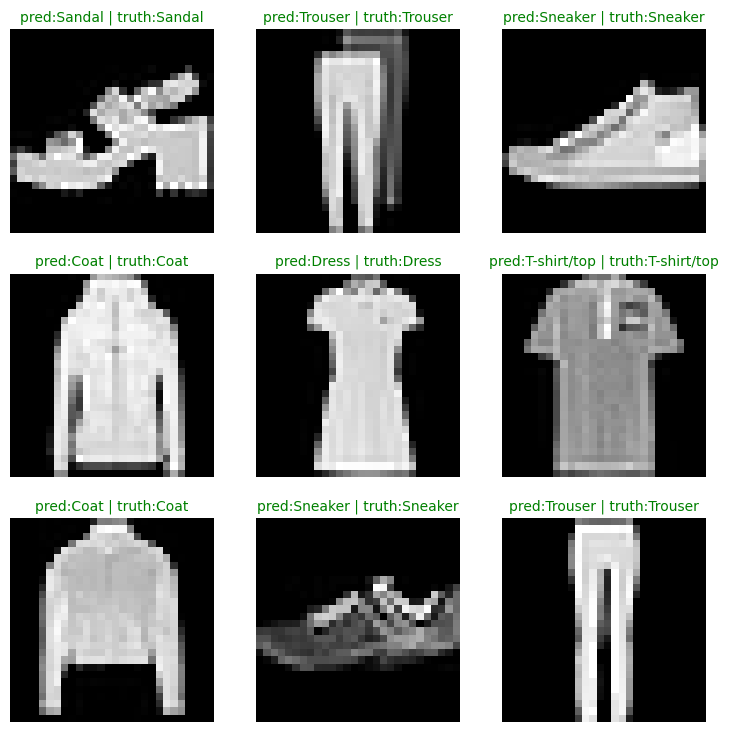

In [55]:
# plot predicions
plt.figure(figsize=(9,9))
nrows=3
ncols=3

for i,sample in enumerate(test_samples):
  plt.subplot(nrows,ncols,i+1)
  plt.imshow( sample.squeeze(),cmap="gray")
  # find prediction
  pred_label=class_names[pred_classes[i]]
  # get the truth label(in text form)
  truth_label = class_names[test_labels[i]]

  title_text= f"pred:{pred_label} | truth:{truth_label}"
  if pred_label == truth_label:
    plt.title(title_text,fontsize=10,color="green")
  else:
    plt.title(title_text,fontsize=10,color="red")
  plt.axis(False)


### save and load best performing model

In [56]:
from pathlib import Path
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True,exist_ok=True)
MODEL_NAME = "fashion_mnist_model_2.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

MODEL_SAVE_PATH

PosixPath('models/fashion_mnist_model_2.pth')

In [57]:
# SAVE THE MODEL STATE DICT
print(f"saving model to:{MODEL_SAVE_PATH}")
torch.save(obj=model_2.state_dict(),
           f=MODEL_SAVE_PATH)
#


saving model to:models/fashion_mnist_model_2.pth


In [73]:
torch.manual_seed(42)
loaded_model_2 = FashionMNISTModelv2(input_shape=1,
                                      hidden_units=10,
                                      output_shape=len(class_names)).to(device)
loaded_model_2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))
loaded_model_2.to(device)



FashionMNISTModelv2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [74]:
model_2_results

{'model_name': 'FashionMNISTModelv2',
 'model_loss': 0.3214859068393707,
 'model_acc': 88.37859424920129}

In [75]:
loaded_model_2_results = eval_model(model=loaded_model_2,
                                     data_loader=test_dataloader,
                                     loss_fn=loss_fn,
                                     accuracy_fn=accuracy_fn,
                                     device=device)

In [77]:
loaded_model_2_results

{'model_name': 'FashionMNISTModelv2',
 'model_loss': 0.3214859068393707,
 'model_acc': 88.37859424920129}